# Assignment 3
### Due 9/23. Do four of five.

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [ ]:
import os
import pandas as pd
import seaborn as sns

os.chdir("/Users/mta/Desktop/Understanding Uncertainty/MTA4KD/data")

data = pd.read_csv("nhanes_data_17_18.csv")
meta = pd.read_csv("nhanes_meta_17_18.csv")

print("Participants:", data.shape[0])
print("Variables:", data.shape[1])
print("Metadata variables:", meta.shape[0])

display(data.head())
display(meta[['Variable', 'Label', 'Target']].head(200))

Participants: 8366
Variables: 198
Metadata variables: 197


/var/folders/_x/p9ds2_7j4cg3964ybwvy6rh00000gn/T/ipykernel_83926/1819090293.py:9: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("nhanes_data_17_18.csv")


,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,...,DaysSmokedCigsDuringPast30Days,AvgCigarettesdayDuringPast30Days,TriedToQuitSmoking,TimesStoppedSmokingCigarettes,HowLongWereYouAbleToStopSmoking,UnitOfMeasureDayweekmonthyear_2_SMQ,CurrentSelfreportedHeightInches,CurrentSelfreportedWeightPounds,TriedToLoseWeightInPastYear,TimesLost10LbsOrMoreToLoseWeight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Variable,Label,Target
0,HSD010,General health condition,Both males and females 12 YEARS -\n\n\t\t\t15...
1,DBQ010,Ever breastfed or fed breastmilk,Both males and females 0 YEARS -\n\n\t\t\t6 Y...
2,DBD030,Age stopped breastfeeding(days),Both males and females 0 YEARS -\n\n\t\t\t6 Y...
3,DBD041,Age first fed formula(days),Both males and females 0 YEARS -\n\n\t\t\t6 Y...
4,DBD050,Age stopped receiving formula(days),Both males and females 0 YEARS -\n\n\t\t\t6 Y...
...,...,...,...
192,SMQ852U,Unit of measure (day/week/month/year),Both males and females 18 YEARS -\n\n\t\t\t15...
193,WHD010,Current self-reported height (inches),Both males and females 16 YEARS -\n\n\t\t\t15...
194,WHD020,Current self-reported weight (pounds),Both males and females 16 YEARS -\n\n\t\t\t15...
195,WHQ070,Tried to lose weight in past year,Both males and females 16 YEARS -\n\n\t\t\t15...


I'm choosing to analyze 1) Race/Hispanic origin w/ NH Asian (RIDRETH3) and 2) Doctor ever said you had arthritis (MCQ160A). These are both categorical variables.

In [33]:
print([col for col in data.columns if "Race" in col])
print([col for col in data.columns if "Arth" in col or "arth" in col])

['RacehispanicOrigin', 'RacehispanicOriginWNhAsian']
['DoctorEverSaidYouHadArthritis']


In [34]:
print(meta.columns.tolist())

['VariableNameLong', 'Variable', 'Type', 'Format', 'Informat', 'Label', 'Source', 'VariableName', 'SASLabel', 'EnglishText', 'Target', 'VariableNameLong_variable_df', 'Source_variable_df', 'EnglishInstructions', 'HardEdits', 'Recoded', 'CustomRecoding', 'nNonNA']


In [ ]:
col_race = "RacehispanicOriginWNhAsian"
col_arthritis = "DoctorEverSaidYouHadArthritis"

for var_id, col in [("RIDRETH3", col_race), ("MCQ160A", col_arthritis)]:
    missing_pct = data[col].isna().mean() * 100
    print(f"{col} ({var_id}) - Missing: {missing_pct:.2f}%")

def summarize_categories(var_id, col_name):
    meta_info = meta[meta["Variable"] == var_id][["Variable", "EnglishText", "Label"]]
    print(f"\n--- {col_name} ({var_id}) ---")
    print(meta_info.to_string(index=False))
    
    counts = data[col_name].value_counts(dropna=False).reset_index()
    counts.columns = [col_name, "Frequency"]
    print(counts)

summarize_categories("RIDRETH3", col_race)
summarize_categories("MCQ160A", col_arthritis)

RacehispanicOriginWNhAsian (RIDRETH3) - Missing: 0.00%
DoctorEverSaidYouHadArthritis (MCQ160A) - Missing: 37.25%

--- RacehispanicOriginWNhAsian (RIDRETH3) ---
Variable                                                                               EnglishText                            Label
RIDRETH3 Recode of reported race and Hispanic origin information, with Non-Hispanic Asian Category Race/Hispanic origin w/ NH Asian
            RacehispanicOriginWNhAsian  Frequency
0                   Non-Hispanic White       2792
1                   Non-Hispanic Black       1949
2                     Mexican American       1229
3                   Non-Hispanic Asian       1083
4                       Other Hispanic        738
5  Other Race - Including Multi-Racial        575

--- DoctorEverSaidYouHadArthritis (MCQ160A) ---
Variable                                                                                                    EnglishText                              Label
 MCQ160A Has a doctor 

In [ ]:
selected_vars = [col_race, col_arthritis]

missing_counts = pd.DataFrame({
    var: data[var].isna().value_counts()
    for var in selected_vars
}).T

missing_pct = pd.DataFrame({
    var: data[var].isna().value_counts(normalize=True) * 100
    for var in selected_vars
}).T

print("\nMissingness Counts")
print(missing_counts)

print("\nMissingness Percentages")
print(missing_pct.round(2))


Missingness Counts
                                False   True 
RacehispanicOriginWNhAsian     8366.0     NaN
DoctorEverSaidYouHadArthritis  5250.0  3116.0

Missingness Percentages
                                False  True 
RacehispanicOriginWNhAsian     100.00    NaN
DoctorEverSaidYouHadArthritis   62.75  37.25


In [ ]:
contingency_counts = pd.crosstab(
    data[col_race],
    data[col_arthritis],
    margins=True,
    dropna=False
)

contingency_row_pct = pd.crosstab(
    data[col_race],
    data[col_arthritis],
    normalize="index",   
    dropna=False
) * 100

contingency_col_pct = pd.crosstab(
    data[col_race],
    data[col_arthritis],
    normalize="columns",
    dropna=False
) * 100

print("\nContingency Table: Counts")
print(contingency_counts)

print("\nContingency Table: Row Percentages (within each race)")
print(contingency_row_pct.round(2))

print("\nContingency Table: Column Percentages (within arthritis response)")
print(contingency_col_pct.round(2))


Contingency Table: Counts
DoctorEverSaidYouHadArthritis         0.0   1.0  NaN   All
RacehispanicOriginWNhAsian                                
Mexican American                      544   152  533  1229
Non-Hispanic Asian                    636   121  326  1083
Non-Hispanic Black                    841   395  713  1949
Non-Hispanic White                   1097   707  988  2792
Other Hispanic                        359   133  246   738
Other Race - Including Multi-Racial   168    97  310   575
All                                  3645  1605    0  8366

Contingency Table: Row Percentages (within each race)
DoctorEverSaidYouHadArthritis          0.0    1.0    NaN
RacehispanicOriginWNhAsian                              
Mexican American                     44.26  12.37  43.37
Non-Hispanic Asian                   58.73  11.17  30.10
Non-Hispanic Black                   43.15  20.27  36.58
Non-Hispanic White                   39.29  25.32  35.39
Other Hispanic                       48.64  1

<div style="color:red">
Looking at the contingency table, two things jump out. First, the row percentages: within each race, Non-Hispanic Whites have the highest reported arthritis rate (about 25%), followed by Non-Hispanic Blacks (20%). Mexican Americans and Asians are lower, closer to 12%. So prevalence clearly isn’t even across groups. Second, the column percentages: when you look at the arthritis “Yes” pool, it’s dominated by Whites (44%) and Blacks (25%), meaning those two groups make up the bulk of reported arthritis cases in this dataset. The big caveat is missingness — it’s huge, 30–50% depending on the group — so you can’t treat these as clean prevalence estimates. Still, the directional pattern is obvious: arthritis is more common among Whites and Blacks, less so among Mexican Americans and Asians.
</div>

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

<div style="color:red">
I'm choosing to analyze 1) Weight KG (BMXWT) and 2) Doctor ever said you had arthritis (MCQ160A). 
<div>

DoctorEverSaidYouHadArthritis - Missing: 37.25%
WeightKg - Missing: 1.48%

Descriptive Statistics (Weight by Arthritis status):
                                count       mean        std   min   25%   50%  \
DoctorEverSaidYouHadArthritis                                                   
0.0                            3600.0  81.367611  22.227085  32.6  66.1  77.7   
1.0                            1573.0  86.150223  23.990346  39.3  69.3  82.6   

                                75%    max  
DoctorEverSaidYouHadArthritis               
0.0                            92.7  242.6  
1.0                            98.8  219.6  


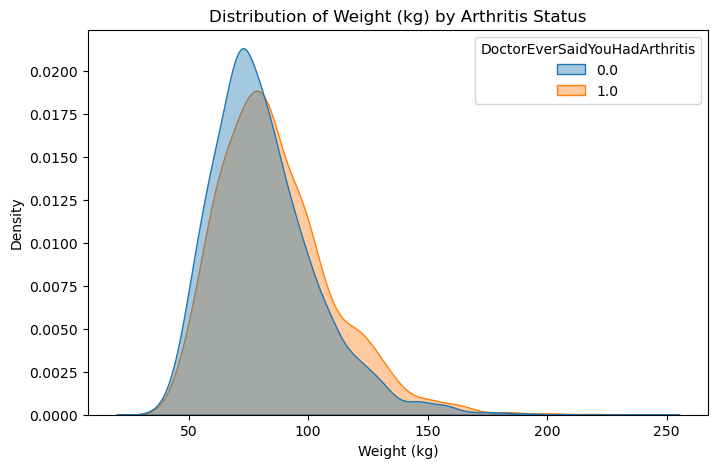

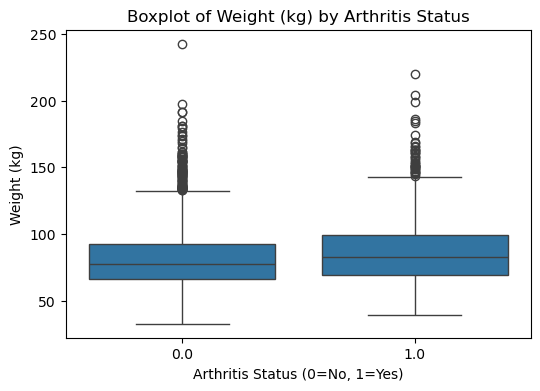

In [ ]:
col_cat = "DoctorEverSaidYouHadArthritis"   
col_num = "WeightKg"                        


for col in [col_cat, col_num]:
    missing_pct = data[col].isna().mean() * 100
    print(f"{col} - Missing: {missing_pct:.2f}%")

desc_stats = data.groupby(col_cat)[col_num].describe()
print("\nDescriptive Statistics (Weight by Arthritis status):")
print(desc_stats)

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=data,
    x=col_num,
    hue=col_cat,
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.title("Distribution of Weight (kg) by Arthritis Status")
plt.xlabel("Weight (kg)")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=data,
    x=col_cat,
    y=col_num
)
plt.title("Boxplot of Weight (kg) by Arthritis Status")
plt.xlabel("Arthritis Status (0=No, 1=Yes)")
plt.ylabel("Weight (kg)")
plt.show()

<div style="color:red">
Looking at the stats and plots, there’s a clear weight gap between people who reported arthritis and those who didn’t. Average weight is about 86 kg in the arthritis group vs 81 kg in the no-arthritis group. The kernel density plot shows the arthritis group’s distribution shifted slightly to the right — heavier on average, with a longer right tail. The boxplot tells the same story: higher median and more extreme outliers among those with arthritis. Missingness is low here (~1.5% for weight, ~37% for arthritis status), so this pattern isn’t just noise. The takeaway is straightforward: in this sample, higher weight tracks with higher arthritis prevalence.
</div>

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

<div style="color:red">

$$
MSE(\hat{y}(z)) = \frac{1}{N}\sum_{i=1}^N (y_i - \hat{y}(z))^2 \, w_i(z),
\quad 
w_i(z) = \frac{1}{h} k\!\left(\frac{z - x_i}{h}\right).
$$

---

**Step 1: Differentiate wrt $\hat{y}(z)$**

$$
\frac{\partial}{\partial \hat{y}(z)} MSE(\hat{y}(z)) 
= \frac{1}{N}\sum_{i=1}^N 2(\hat{y}(z) - y_i) w_i(z)
= \frac{2}{N}\Bigg[\hat{y}(z)\sum_{i=1}^N w_i(z) - \sum_{i=1}^N w_i(z) y_i\Bigg].
$$

---

**Step 2: Set equal to zero and solve**

$$
\hat{y}(z)\sum_{i=1}^N w_i(z) = \sum_{i=1}^N w_i(z) y_i,
$$

$$
\hat{y}(z) = \frac{\sum_{i=1}^N w_i(z) y_i}{\sum_{i=1}^N w_i(z)}.
$$

---

**Step 3: Plug back in kernel weights**

Since

$$
w_i(z) = \frac{1}{h} k\!\left(\frac{z - x_i}{h}\right),
$$

we get:

$$
\hat{y}(z) = \frac{\sum_{i=1}^N k\!\left(\frac{z - x_i}{h}\right) y_i}
{\sum_{i=1}^N k\!\left(\frac{z - x_i}{h}\right)}.
$$

---

This is the **Nadaraya–Watson estimator** - a weighted average of the $y_i$’s, with weights coming from the kernel.

- Small $h$: sharp, twitchy, low bias, high variance. Like trading tick-by-tick — overfit and volatile.  
- Large $h$: smooth, flat, high bias, low variance. Like averaging across decades — stable, but you miss the details.  

The *estimator* is just balancing how much noise we want to eat versus how much structure we’re willing to miss.

</div>

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

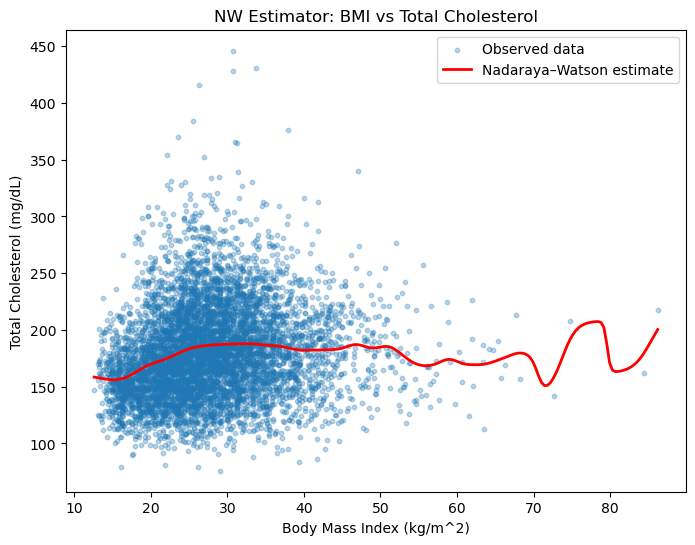

Descriptive stats:
       BodyMassIndexKgm2  TotalCholesterolMgdl
count        6641.000000           6641.000000
mean           27.833444            179.982232
std             7.913572             40.647648
min            12.600000             76.000000
25%            22.300000            150.000000
50%            26.900000            176.000000
75%            32.100000            204.000000
max            86.200000            446.000000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

col_x = "BodyMassIndexKgm2"     
col_y = "TotalCholesterolMgdl"  

subset = data[[col_x, col_y]].dropna()
X = subset[col_x].values
Y = subset[col_y].values


n = len(X)
h = 1.06 * np.std(X) * n ** (-1/5)

def nw_estimator(x0, X, Y, h):
    weights = norm.pdf((x0 - X) / h)
    return np.sum(weights * Y) / np.sum(weights)

x_grid = np.linspace(X.min(), X.max(), 200)
y_hat = np.array([nw_estimator(x0, X, Y, h) for x0 in x_grid])

plt.figure(figsize=(8,6))
plt.scatter(X, Y, s=10, alpha=0.3, label="Observed data")
plt.plot(x_grid, y_hat, color="red", lw=2, label="Nadaraya–Watson estimate")
plt.xlabel("Body Mass Index (kg/m^2)")
plt.ylabel("Total Cholesterol (mg/dL)")
plt.title("NW Estimator: BMI vs Total Cholesterol")
plt.legend()
plt.show()

print("Descriptive stats:")
print(subset.describe())

<div style="color:red">
The scatterplot shows the relationship between BMI and Total Cholesterol. The raw data are highly variable, but the Nadaraya–Watson estimator provides a smoothed curve that highlights the average trend. Cholesterol levels tend to increase slightly as BMI rises from low to mid-range, then flatten, with some increase again at higher BMI values.

The descriptive statistics confirm the wide spread in both variables: BMI (std ≈ 7.9) and cholesterol (std ≈ 49.6). Missingness is relatively modest for BMI (≈4%) but higher for cholesterol (≈19%).

Overall, the estimator suggests a weak positive association between BMI and cholesterol, though with considerable noise. The pattern indicates that individuals with higher BMI often show higher cholesterol on average, but the relationship is far from deterministic, and there is substantial variation across the range of BMI values.
</div>

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome